In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output


In [2]:
np.random.seed(42)

In [3]:
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Subsample the dataset
sample_size = 5000
X_sample = X.sample(sample_size, random_state=42)
y_sample = y[X_sample.index]


In [4]:
X_sample

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01
3024,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46
15663,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44
20484,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72
9814,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93
...,...,...,...,...,...,...,...,...
12107,4.7110,27.0,6.535885,1.016746,2400.0,2.870813,33.99,-117.32
13881,3.2077,9.0,5.896552,1.050157,3166.0,3.308255,34.42,-117.27
420,6.6828,52.0,7.353175,1.053571,1205.0,2.390873,37.89,-122.26
284,3.6875,42.0,5.707865,0.973783,651.0,2.438202,37.78,-122.17


In [6]:
y_sample.shape

(5000,)

In [8]:
X.shape

(20640, 8)

In [7]:
print("Original Dataset Shape:", X.shape)
print("Sampled Dataset Shape:", X_sample.shape)
print("Target Range:", y_sample.min(), "to", y_sample.max())
print("Feature Names:", X_sample.columns.tolist())

Original Dataset Shape: (20640, 8)
Sampled Dataset Shape: (5000, 8)
Target Range: 0.14999 to 5.00001
Feature Names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [9]:
print(X_sample.isnull().sum().sum(), "missing values found")

0 missing values found


In [10]:
X_sample.duplicated().sum()

0

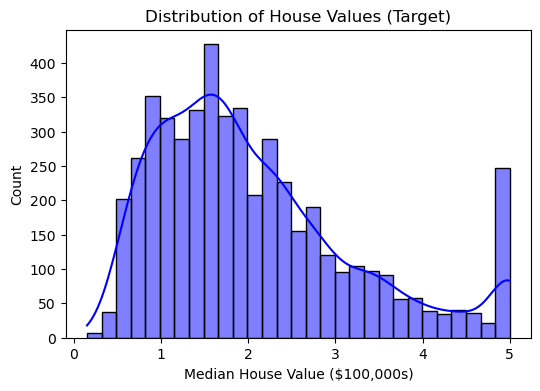

In [11]:
plt.figure(figsize=(6, 4))
sns.histplot(y_sample, kde=True, color='blue')
plt.title('Distribution of House Values (Target)')
plt.xlabel('Median House Value ($100,000s)')
plt.ylabel('Count')
plt.show()

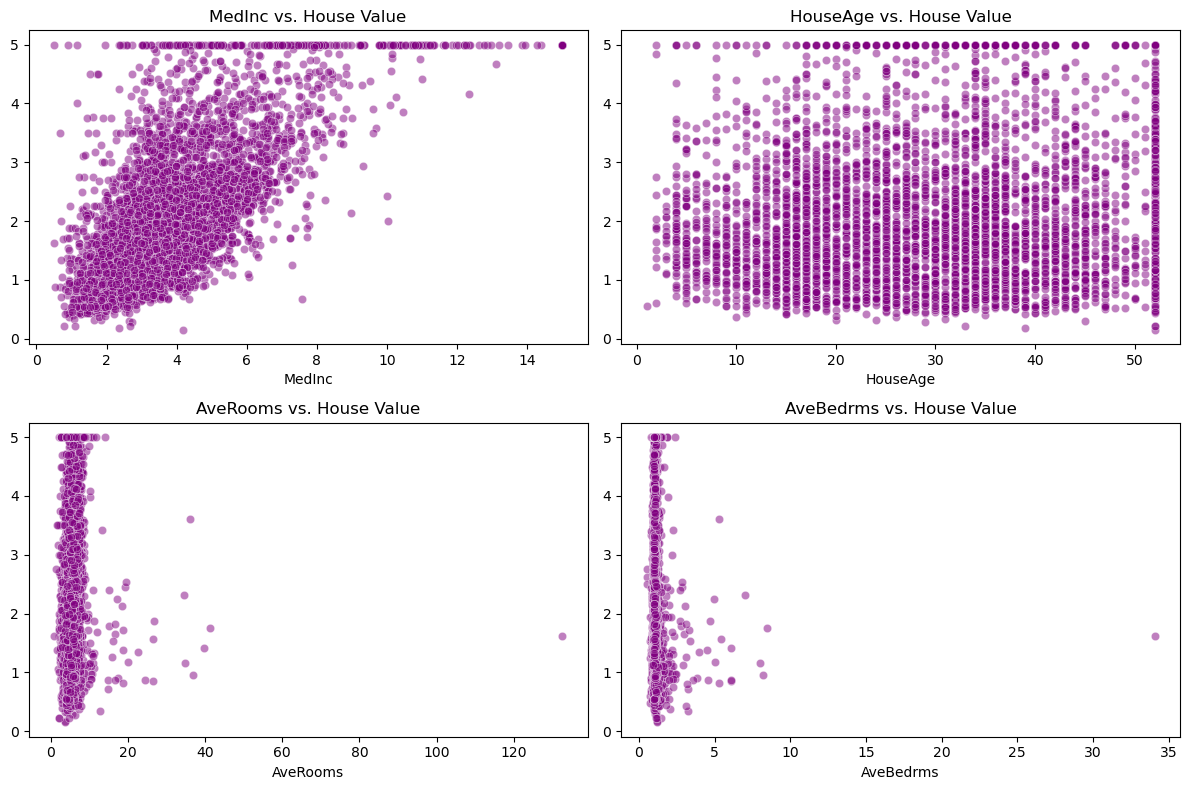

In [16]:
# Visualize feature distributions (example: first 4 features)
plt.figure(figsize=(12, 8))
for i, feature in enumerate(X_sample.columns[:4]):
    plt.subplot(2, 2, i+1)
    sns.scatterplot(x=X_sample[feature], y=y_sample, color='purple', alpha=0.5)
    plt.title(f'{feature} vs. House Value')
    plt.tight_layout()
plt.show()

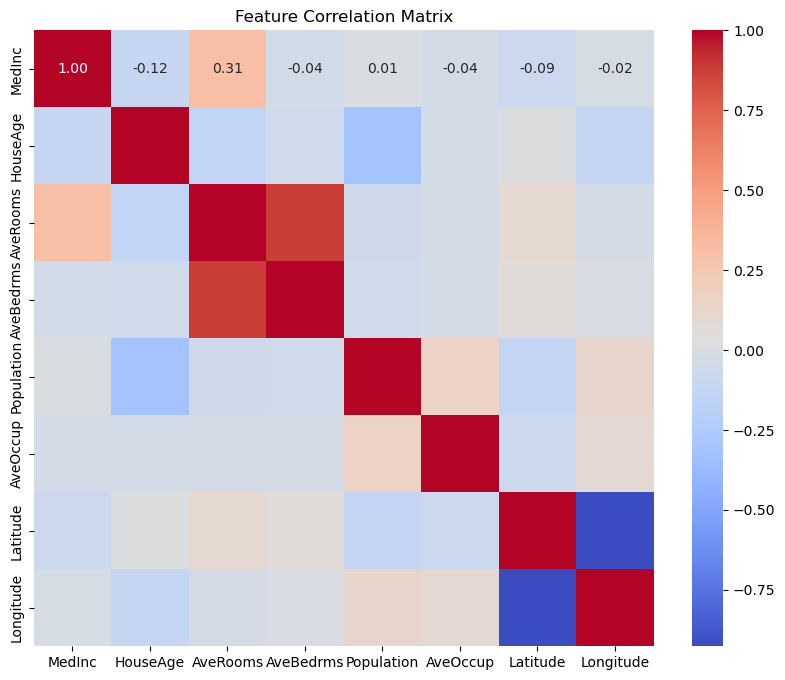

In [17]:
plt.figure(figsize=(10, 8))
sns.heatmap(X_sample.corr(), cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()


In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)
X_scaled = pd.DataFrame(X_scaled, columns=X_sample.columns)

In [21]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"Explained Variance Ratio by PCA: {pca.explained_variance_ratio_}")

Explained Variance Ratio by PCA: [0.25845662 0.23803448]


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_sample, test_size=0.2, random_state=42)
print("\nTraining Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)


Training Set Shape: (4000, 8)
Testing Set Shape: (1000, 8)


In [23]:
svr = SVR(kernel='rbf')
svr.fit(X_train, y_train)
print("\nInitial SVR Model Trained (Default Parameters)")


Initial SVR Model Trained (Default Parameters)


In [24]:
y_train_pred = svr.predict(X_train)
y_test_pred = svr.predict(X_test)


In [26]:
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

In [27]:
print("\nInitial Model Evaluation:")
print(f"Training MSE: {train_mse:.4f}")
print(f"Test MSE: {test_mse:.4f}")
print(f"Training MAE: {train_mae:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Training R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")


Initial Model Evaluation:
Training MSE: 0.3084
Test MSE: 0.3620
Training MAE: 0.3718
Test MAE: 0.4076
Training R²: 0.7649
Test R²: 0.7320


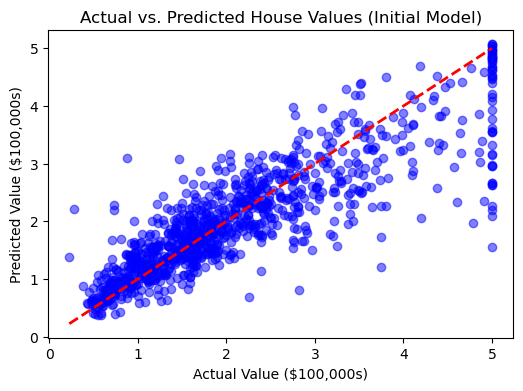

In [28]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_test_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted House Values (Initial Model)')
plt.xlabel('Actual Value ($100,000s)')
plt.ylabel('Predicted Value ($100,000s)')
plt.show()


In [29]:
def plot_svr_predictions(X, y, model, kernel_name):
    model.fit(X, y)
    y_pred = model.predict(X)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], y, color='purple', label='Actual', alpha=0.5)
    plt.scatter(X[:, 0], y_pred, color='orange', label='Predicted', alpha=0.5)
    plt.title(f'SVR Predictions with {kernel_name} Kernel (PCA Component 1)')
    plt.xlabel('PCA Component 1')
    plt.ylabel('House Value ($100,000s)')
    plt.legend()
    plt.show()

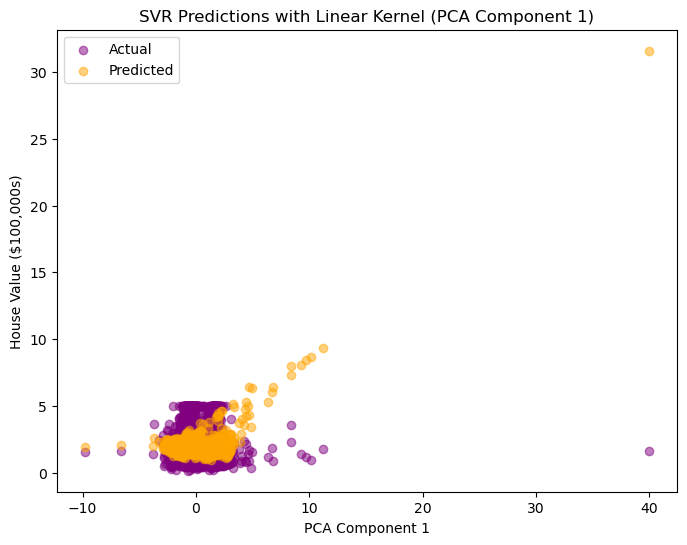

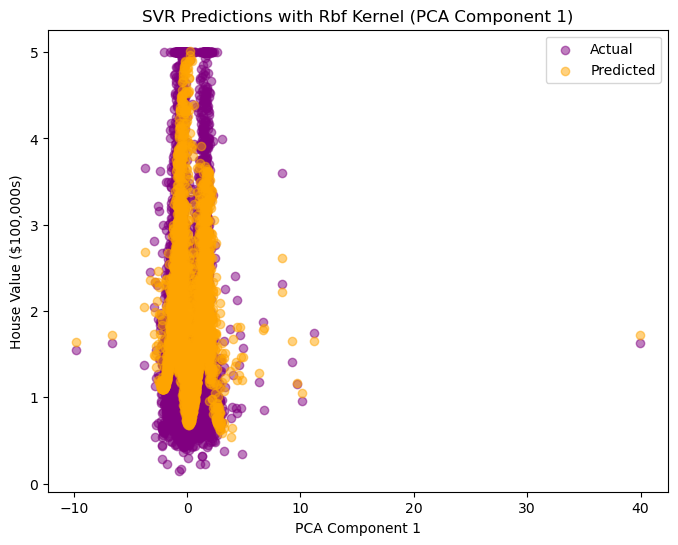

In [30]:
kernels = ['linear', 'rbf']
for kernel in kernels:
    svr_vis = SVR(kernel=kernel)
    plot_svr_predictions(X_pca, y_sample, svr_vis, kernel.capitalize())

In [36]:
param_grid = {
    'C': [0.1,0.05, 1, 10],
    'kernel': ['linear', 'rbf','poly','sigmoid'],
    'gamma': ['scale', "auto"],
    'epsilon': [0.1, 0.5, 0.01]
}


In [37]:
grid_search = GridSearchCV(SVR(), param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)

In [38]:
grid_search.fit(X_train, y_train)
print("\nBest Parameters from Grid Search:", grid_search.best_params_)
print("Best Cross-Validation MSE:", -grid_search.best_score_)


Best Parameters from Grid Search: {'C': 10, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross-Validation MSE: 0.32233560141030143


In [39]:
best_model = grid_search.best_estimator_
y_test_pred_tuned = best_model.predict(X_test)

In [40]:
test_mse_tuned = mean_squared_error(y_test, y_test_pred_tuned)
test_mae_tuned = mean_absolute_error(y_test, y_test_pred_tuned)
test_r2_tuned = r2_score(y_test, y_test_pred_tuned)

print("\nTuned Model Evaluation:")
print(f"Test MSE (Tuned): {test_mse_tuned:.4f}")
print(f"Test MAE (Tuned): {test_mae_tuned:.4f}")
print(f"Test R² (Tuned): {test_r2_tuned:.4f}")


Tuned Model Evaluation:
Test MSE (Tuned): 0.3593
Test MAE (Tuned): 0.4025
Test R² (Tuned): 0.7340
